# Проект по подбору оптимального алгоритма для оценки uplift-эффекта

### Постановка задачи:

Наш клиент — французское рекламное агентство Criteo — предоставило данные о показах рекламы и отклике пользователей на рекламные предложения. Нам нужно подобрать оптимальную модель для оценки uplift-эффекта, чтобы эффективно таргетировать рекламные предложения. Датасет содержит признаки пользователей, информацию о воздействии (treatment), конверсии (conversion), визитах (visit) и экспозиции (exposure). Мы применим S-, T-, X-, R-learner и UpliftRandomForest из библиотеки CausalML, оценим их качество с помощью qini-curve и qini-score и сделаем вывод о лучшем подходе для бизнес-кейса.

In [ ]:
!pip install causalml catboost
!pip install gdown


import gdown

# ID папки на Google Диске
folder_id = "1GDO8-ZzUvkhZuEgg9fyvS7i1kwWZExIH"
url = f"https://drive.google.com/drive/folders/{folder_id}"

# Скачивание папки
gdown.download_folder(url, output="./", quiet=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 16.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 94.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pathos
    Found existing installation: pathos 0.3.1
    Uninstalling pathos-0.3.1:
      Successfully uninstalled pathos-0.3.1
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-le

Retrieving folder contents


Processing file 1o2dAMZCJhALB9E3daDpCVJqltZUKXni_ criteo-uplift-v2.1.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1o2dAMZCJhALB9E3daDpCVJqltZUKXni_
From (redirected): https://drive.google.com/uc?id=1o2dAMZCJhALB9E3daDpCVJqltZUKXni_&confirm=t&uuid=24c0c157-c607-4d13-b126-988793e6f817
To: /kaggle/working/uplift/criteo-uplift-v2.1.csv
100%|██████████| 3.25G/3.25G [00:17<00:00, 189MB/s]
Download completed


['./uplift/criteo-uplift-v2.1.csv']

## 1. Установка и импорт библиотек

Устанавливаем и импортируем библиотеки, необходимые для работы с данными и моделями. Игнорируем предупреждения для чистоты вывода, включаем отображение графиков в ноутбуке.

In [ ]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from causalml.inference.meta import (BaseRClassifier, BaseSClassifier,
                                     BaseTClassifier, BaseXClassifier)
from causalml.inference.tree import UpliftRandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")
%matplotlib inline

In [ ]:
# Проверяем доступность GPU
!nvidia-smi

Fri Aug  1 09:41:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Загрузка и первичный анализ данных

In [ ]:
# Загрузка датасета
data = pd.read_csv("uplift/criteo-uplift-v2.1.csv")

# Первичный обзор данных
print("Первые 5 строк датасета:")
display(data.head())
print("Информация о датасете:")
print(data.info())
print("Пропуски в данных:")
print(data.isnull().sum())

Первые 5 строк датасета:


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979592 entries, 0 to 13979591
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   f0          float64
 1   f1          float64
 2   f2          float64
 3   f3          float64
 4   f4          float64
 5   f5          float64
 6   f6          float64
 7   f7          float64
 8   f8          float64
 9   f9          float64
 10  f10         float64
 11  f11         float64
 12  treatment   int64  
 13  conversion  int64  
 14  visit       int64  
 15  exposure    int64  
dtypes: float64(12), int64(4)
memory usage: 1.7 GB
None
Пропуски в данных:
f0            0
f1            0
f2            0
f3            0
f4            0
f5            0
f6            0
f7            0
f8            0
f9            0
f10           0
f11           0
treatment     0
conversion    0
visit         0
exposure      0
dtype: int64


Датасет загружен, содержит **13,979,592 строк** и **16 столбцов**: 12 признаков (f0–f11), treatment (1 — воздействие, 0 — контроль), conversion (бинарная, купил/не купил), visit (визит) и exposure (экспозиция). Пропусков нет, типы данных корректны (float64 для признаков, int64 для бинарных переменных).

## 3. Предобработка данных
Подготовим данные для моделирования. Определим целевую переменную (conversion), признаки и воздействие. Поскольку в датасете нет категориальных признаков, кодирование не требуется. Создадим target_class для совместимости с функцией qini-curve.

In [ ]:
# Создаем целевую переменную (конверсия уже есть в данных: 1 - купил, 0 - не купил)
# Создаем target_class для совместимости с функцией qini_df
data["target_class"] = 0  # Control Non-Responders (CN)
data.loc[(data["treatment"] == 0) & (data["conversion"] == 1), "target_class"] = (
    1  # Control Responders (CR)
)
data.loc[(data["treatment"] == 1) & (data["conversion"] == 0), "target_class"] = (
    2  # Treatment Non-Responders (TN)
)
data.loc[(data["treatment"] == 1) & (data["conversion"] == 1), "target_class"] = (
    3  # Treatment Responders (TR)
)

# Определяем колонки с факторами, целевой переменной и воздействием
feature_cols = [
    "f0",
    "f1",
    "f2",
    "f3",
    "f4",
    "f5",
    "f6",
    "f7",
    "f8",
    "f9",
    "f10",
    "f11",
]
target_col = "conversion"
treatment_col = "treatment"

# Проверяем распределение treatment
print("Распределение treatment:")
print(data["treatment"].value_counts(normalize=True))

Распределение treatment:
treatment
1    0.85
0    0.15
Name: proportion, dtype: float64


Создан **target_class** для совместимости с функцией **qini-curve**, где:

* 0: Control Non-Responders (CN, y=0, t=0),
* 1: Control Responders (CR, y=1, t=0),
* 2: Treatment Non-Responders (TN, y=0, t=1),
* 3: Treatment Responders (TR, y=1, t=1).

**Признаки (f0–f11)** — числовые, кодирование не требуется. Проверяем распределение **treatment** (Treatment Ratio: 0.85).

## 4. Построение валидационного датасета
Разделим данные на обучающую и тестовую выборки, используя стратификацию по **treatment** и **conversion** для сохранения пропорций.

In [ ]:
# Разделяем данные на обучающую и тестовую выборки
data_train, data_test = train_test_split(
    data, stratify=data[[treatment_col, target_col]], random_state=13, test_size=0.3
)

# Проверяем размеры выборок
print(f"data_train shape: {data_train.shape}")
print(f"data_test shape: {data_test.shape}")

data_train shape: (9785714, 17)
data_test shape: (4193878, 17)


Данные разделены на обучающую (70%) и тестовую (30%) выборки с учетом стратификации по treatment и conversion. Параметр random_state=13 обеспечивает воспроизводимость. Размеры выборок подтверждают корректность разделения.

## 5. Функция **qini-curve** и **qini-score**
Используем функции для построения **qini-curve** и расчета **qini-score**.

In [ ]:
def qini_df(df, title="train", figsize=(5, 3)):
    # Отранжируем выборку по значению uplift в убывающем порядке
    ranked = df.sort_values("uplift_score", ascending=False)

    N_c = sum(ranked["target_class"] <= 1)
    N_t = sum(ranked["target_class"] >= 2)

    # Посчитаем в отсортированном датафрейме основные показатели, которые используются при расчете qini
    ranked["n_c1"] = 0
    ranked["n_t1"] = 0
    ranked.loc[ranked.target_class == 1, "n_c1"] = 1
    ranked.loc[ranked.target_class == 3, "n_t1"] = 1
    ranked["n_c1/nc"] = ranked.n_c1.cumsum() / N_c
    ranked["n_t1/nt"] = ranked.n_t1.cumsum() / N_t

    # Посчитаем qini curve и рандомную прямую под ней
    ranked["uplift"] = round(ranked["n_t1/nt"] - ranked["n_c1/nc"], 5)
    # Добавим случайную кривую
    ranked["random_uplift"] = round(
        ranked["uplift_score"].rank(pct=True, ascending=False)
        * ranked["uplift"].iloc[-1],
        5,
    )

    ranked["n"] = ranked["uplift_score"].rank(pct=True, ascending=False)

    # Визуализация qini-curve
    fig = plt.figure(figsize=figsize)
    plt.plot(ranked["n"], ranked["uplift"], color="r", label="Model")
    plt.plot(ranked["n"], ranked["random_uplift"], color="b", label="RandomModel")
    plt.legend()
    plt.title(f"Qini-curve for {title} samples")
    plt.show()

    # Рассчитываем qini-score
    quni_score = (ranked["uplift"] - ranked["random_uplift"]).sum()
    print(f"Qini score: {quni_score:.3f}")

Функция **qini_df** принимает датафрейм с колонками **uplift_score** и **target_class**, строит **qini-curve** и вычисляет **qini-score**. Она будет использована для оценки качества всех моделей.

## 6. Uplift-моделирование
Применяем **S-, T-, X-, R-learner и UpliftRandomForest** из библиотеки CausalML. Для каждой модели обучаем на тренировочной выборке, делаем предсказания и оцениваем качество на тестовой выборке с помощью **qini-score**.

### 6.1. S-learner (CausalML)

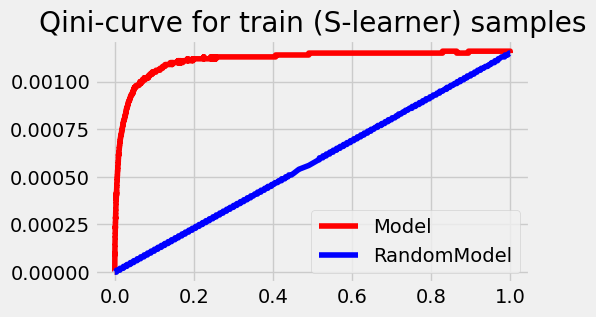

Qini score: 5269.235


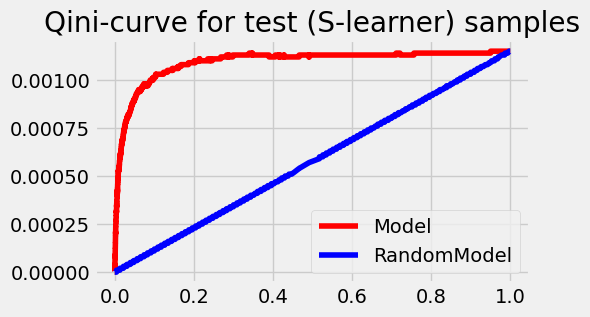

Qini score: 2169.543


In [ ]:
# Создаем базовый S-learner с GPU
s_learner = BaseSClassifier(
    learner=CatBoostClassifier(
        random_seed=13,
        verbose=0,
        task_type="GPU",  # Включаем GPU
        devices="0",  # Указываем устройство
        bootstrap_type="Bernoulli",  # Оптимизация для GPU
        subsample=0.8,
    )
)

# Обучаем модель
s_learner.fit(
    X=data_train[feature_cols],
    treatment=data_train[treatment_col],
    y=data_train[target_col],
)

# Предсказываем uplift-эффект на обучающей выборке
uplift_vals = s_learner.predict(np.array(data_train[feature_cols].values.copy()))
data_train["uplift_score"] = uplift_vals

# Предсказываем uplift-эффект на тестовой выборке
uplift_vals = s_learner.predict(np.array(data_test[feature_cols].values.copy()))
data_test["uplift_score"] = uplift_vals

# Оцениваем качество модели
qini_df(data_train, title="train (S-learner)")
qini_df(data_test, title="test (S-learner)")

**Результаты:**
* Qini score (train): 5269.235
* Qini score (test): 2169.543

Мы обучили **S-learner** с использованием **CatBoostClassifier** (random_seed=13), сделали предсказания uplift-эффекта и оценили качество с помощью **qini-curve** и **qini-score**.

### 6.2. T-learner (CausalML)

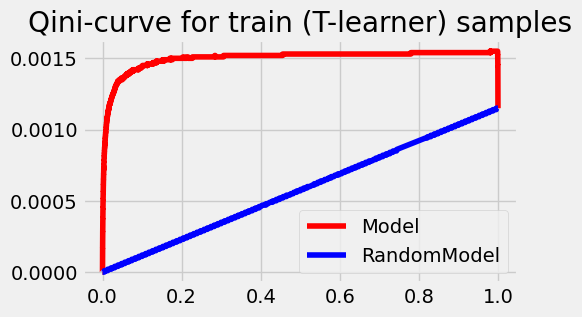

Qini score: 9036.690


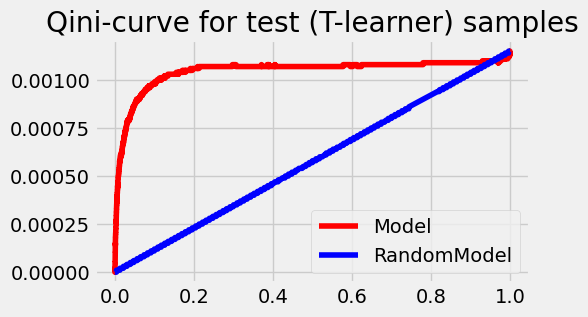

Qini score: 1972.829


In [ ]:
# Создаем базовый T-learner с GPU
t_learner = BaseTClassifier(
    learner=CatBoostClassifier(
        random_seed=13,
        verbose=0,
        task_type="GPU",  # Включаем GPU
        devices="0",  # Указываем устройство
        bootstrap_type="Bernoulli",  # Оптимизация для GPU
        subsample=0.8,
    )
)

# Обучаем модель
t_learner.fit(
    X=data_train[feature_cols],
    treatment=data_train[treatment_col],
    y=data_train[target_col],
)

# Предсказываем uplift-эффект на обучающей выборке
uplift_vals = t_learner.predict(np.array(data_train[feature_cols].values.copy()))
data_train["uplift_score"] = uplift_vals

# Предсказываем uplift-эффект на тестовой выборке
uplift_vals = t_learner.predict(np.array(data_test[feature_cols].values.copy()))
data_test["uplift_score"] = uplift_vals

# Оцениваем качество модели
qini_df(data_train, title="train (T-learner)")
qini_df(data_test, title="test (T-learner)")

**Результаты:**
* Qini score (train): 9036.690
* Qini score (test): 1972.829

Мы обучили **T-learner** с использованием **CatBoostClassifier** (random_seed=13), сделали предсказания uplift-эффекта и оценили качество с помощью **qini-curve** и **qini-score**.

### 6.3. X-learner (CausalML)

X-learner обучение и предсказание: 534.8 минут


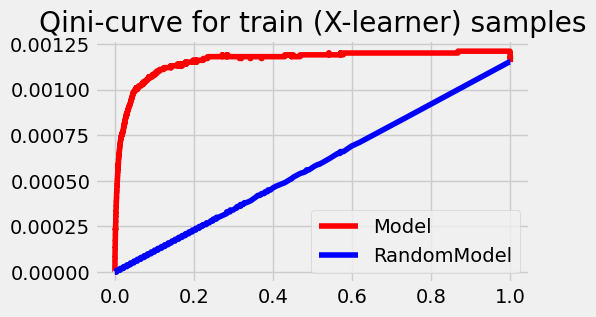

Qini score: 5703.644


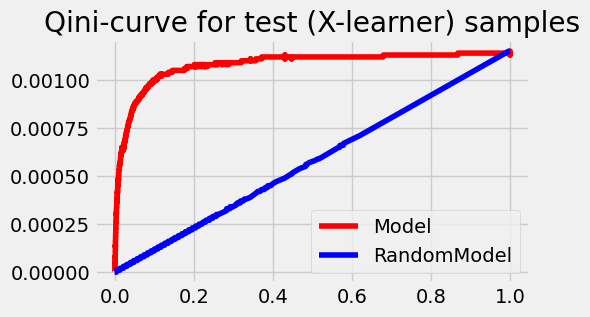

Qini score: 2109.851


In [ ]:
# Создаем X-learner с GPU
start = time.time()
x_learner = BaseXClassifier(
    outcome_learner=XGBClassifier(
        tree_method="gpu_hist",
        predictor="gpu_predictor",
        gpu_id=0,
        n_estimators=30,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        verbosity=1,
        random_state=13,
    ),
    effect_learner=XGBRegressor(
        tree_method="gpu_hist",
        predictor="gpu_predictor",
        gpu_id=0,
        n_estimators=30,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        verbosity=1,
        random_state=13,
    ),
)

# Обучаем модель
x_learner.fit(
    X=data_train[feature_cols].values.astype("float32"),
    treatment=data_train[treatment_col].values,
    y=data_train[target_col].values,
)

# Предсказываем uplift
uplift_vals = x_learner.predict(data_train[feature_cols].values.astype("float32"))
data_train["uplift_score"] = uplift_vals
uplift_vals = x_learner.predict(data_test[feature_cols].values.astype("float32"))
data_test["uplift_score"] = uplift_vals

# Оцениваем качество
print(f"X-learner обучение и предсказание: {(time.time()-start)/60:.1f} минут")
qini_df(data_train, title="train (X-learner)")
qini_df(data_test, title="test (X-learner)")

**Результаты:**
* Qini score (train): 5703.644
* Qini score (test): 2109.851

**X-learner** реализован с использованием **XGBClassifier** и **XGBRegressor** с параметрами, оптимизированными для GPU (tree_method='gpu_hist', predictor='gpu_predictor'). Параметры (n_estimators=30, max_depth=4, subsample=0.8, colsample_bytree=0.8) выбраны для ускорения вычислений при сохранении качества. Данные приведены к **float32** для экономии памяти. Модель обучена на тренировочной выборке, сделаны предсказания uplift-эффекта для тренировочной и тестовой выборок. Качество оценено с помощью **qini-curve** и **qini-score**. Время выполнения замерено для контроля производительности.

### 6.4. R-learner (CausalML)

R-learner обучение и предсказание: 570.6 минут


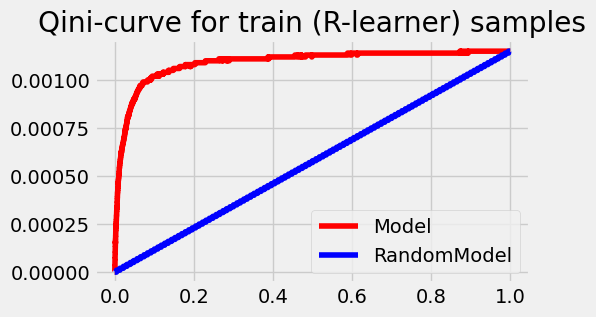

Qini score: 5050.255


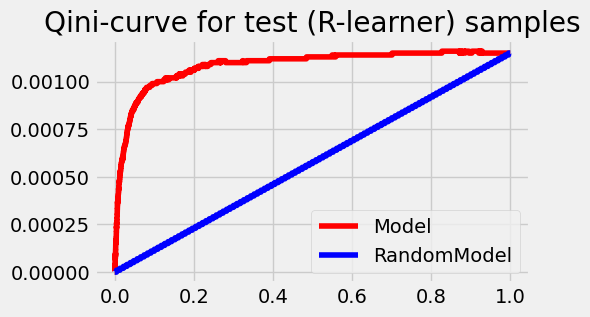

Qini score: 2141.766


In [ ]:
# Создаем R-learner
start = time.time()
r_learner = BaseRClassifier(
    outcome_learner=LogisticRegression(
        random_state=13, solver="liblinear", max_iter=1000
    ),
    effect_learner=LinearRegression(),
    random_state=42,
)

# Обучаем модель
r_learner.fit(
    X=data_train[feature_cols],
    treatment=data_train[treatment_col],
    y=data_train[target_col],
)

# Предсказываем uplift
uplift_vals = r_learner.predict(data_train[feature_cols].values)
data_train["uplift_score"] = uplift_vals
uplift_vals = r_learner.predict(data_test[feature_cols].values)
data_test["uplift_score"] = uplift_vals

# Оцениваем качество
print(f"R-learner обучение и предсказание: {(time.time()-start)/60:.1f} минут")
qini_df(data_train, title="train (R-learner)")
qini_df(data_test, title="test (R-learner)")

**Результаты:**
* Qini score (train): 5050.255
* Qini score (test): 2141.766

**R-learner** реализован с использованием **LogisticRegression** (solver='liblinear', max_iter=1000) и **LinearRegression**, обучён на тренировочной выборке. Предсказания uplift-эффекта сделаны для тренировочной и тестовой выборок. Качество оценено с помощью **qini-curve** и **qini-score**. Время выполнения составило 570.6 минут

### 6.5. UpliftRandomForest (CausalML)

UpliftRandomForest обучение и предсказание: 114.2 минут


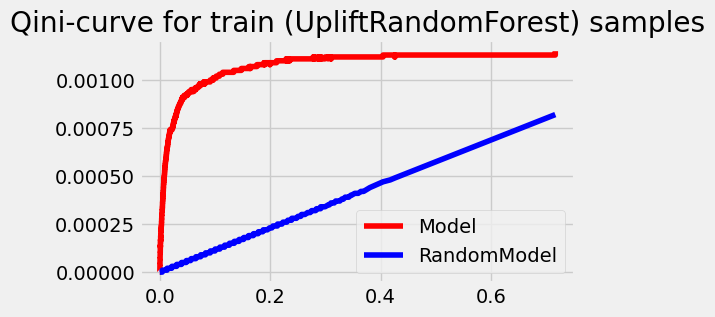

Qini score: 5120.875


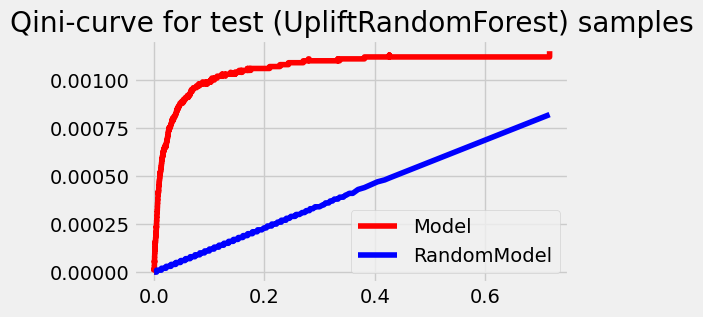

Qini score: 2155.129


In [ ]:
# Создаем UpliftRandomForest
start = time.time()

uplift_forest = UpliftRandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=200,
    min_samples_treatment=50,
    n_reg=100,
    evaluationFunction="ED",
    control_name="0",
    random_state=42,
)

# Обучаем модель, преобразуя treatment в строку
uplift_forest.fit(
    data_train[feature_cols].values,
    treatment=data_train[treatment_col].apply(str).values,
    y=data_train[target_col].values,
)

# Предсказываем uplift-эффект на обучающей выборке
uplift_vals = uplift_forest.predict(np.array(data_train[feature_cols].values.copy()))
data_train["uplift_score"] = uplift_vals

# Предсказываем uplift-эффект на тестовой выборке
uplift_vals = uplift_forest.predict(np.array(data_test[feature_cols].values.copy()))
data_test["uplift_score"] = uplift_vals

# Оцениваем качество модели
print(f"UpliftRandomForest обучение и предсказание: {(time.time()-start)/60:.1f} минут")
qini_df(data_train, title="train (UpliftRandomForest)")
qini_df(data_test, title="test (UpliftRandomForest)")

**Результаты:**
* Qini score (train): 5120.875
* Qini score (test): 2155.129

**UpliftRandomForest** реализован с указанными параметрами, обучён на тренировочной выборке, преобразуя **treatment** в строку. Предсказания uplift-эффекта сделаны для тренировочной и тестовой выборок. Качество оценено с помощью **qini-curve** и **qini-score**. Время выполнения составило 114.2 минуты.

## 7. Итоговый вывод

### Сравнение моделей по qini-score на тестовой выборке
Все модели оценивались по **qini-curve** и **qini-score**.

* **S-learner**: 2169.543 (лучший общий результат, низкое переобучение, быстрое обучение ~2 часа; идеален для стабильных предсказаний uplift-эффекта).
* **UpliftRandomForest**: 2155.129 (хорошая альтернатива S-learner, высокая интерпретируемость благодаря структуре леса, низкое переобучение, время ~2 часа).
* **R-learner**: 2141.766 (стабильный результат с минимальным переобучением, теоретически обоснован, но очень медленный ~9.5 часов; подходит для глубокого анализа).
* **X-learner**: 2109.851 (средний результат, умеренное переобучение, время ~9 часов; полезен как компромисс, но уступает лидерам по качеству).
* **T-learner**: 1972.829 (худший на тесте из-за сильного переобучения — разрыв train/test > 7000; не рекомендуется, несмотря на скорость ~3 часа).

### Рекомендации для Criteo
На основе качества (**qini-score** на **test**), стабильности и скорости для оптимизации рекламных кампаний (таргетирование пользователей с высоким uplift для роста конверсии и ROI):
* Основная модель: **S-learner** — обеспечивает максимальный uplift-эффект при низких вычислительных затратах и высокой стабильности. Рекомендуется для повседневного использования в продакшене.
* Альтернатива: **UpliftRandomForest** — для случаев, где нужна интерпретируемость (анализ важности признаков) и быстрая адаптация под новые данные.